# 不動産投資シミュレーター v1（年次キャッシュフロー分析）

## 目的
単一物件の長期保有における **キャッシュフロー・税引前／税引後収益性・元利返済・売却時損益** を
年次ベースで分析するためのシミュレーターです。

### v0 からの主な変更点
1. **建物構造から法定耐用年数を自動判定** — `building_structure` + `building_usage` → 法定耐用年数
2. **築年数・中古耐用年数の自動計算** — `transaction_date` と `building_completion_ym` から簡便法で算出
3. **インフレ率 + 土地/建物スプレッドによる価格成長** — `component_growth` モードで売却価格を推定
4. **個人/法人の税務モード分岐** — 保有中・売却時の課税を `ownership_type` で切替

### 分析フレームワーク
1. **取得時** — 物件価格・取得諸費用・初期修繕・ローン条件から初期エクイティを算出
2. **保有中** — 年次の NOI・借入返済・税金を計算し、税引前／税引後 CF を時系列で管理
3. **売却時** — 出口 Cap Rate or コンポーネント成長法から売却価格を推定し、ローン残高返済・譲渡税を考慮した手取りを算出

### 主な前提・簡易化
- **年次ベース**（月次は将来拡張）
- 保有期間は 10〜35 年で可変
- 減価償却は **建物部分のみ・定額法**
- 所得税の欠損繰越は **なし**（簡易版）
- Depreciation Recapture は **簡易版**（コメントで留保）
- 大規模修繕 (Capex) は NOI には含めず、キャッシュフロー上で別途管理

In [25]:
# %%
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from copy import deepcopy
from datetime import date, timedelta

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

# --- matplotlib 日本語フォント設定（環境に応じて変更） ---
try:
    import matplotlib
    matplotlib.rcParams["font.family"] = "sans-serif"
    matplotlib.rcParams["font.sans-serif"] = [
        "IPAexGothic", "Noto Sans CJK JP", "Yu Gothic",
        "Hiragino Sans", "DejaVu Sans",
    ]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 日付・建物属性の前処理ヘルパー関数

取引日・築年月のパース、月数計算、法定耐用年数の自動判定などを行うユーティリティ群です。

In [26]:
# %%
# ============================================================
#  日付・月数ヘルパー
# ============================================================

def parse_year_month(ym_str):
    """'YYYY-MM' 形式の文字列を (year, month) タプルに変換する。

    Args:
        ym_str: 'YYYY-MM' 形式の文字列

    Returns:
        tuple[int, int]: (year, month)
    """
    parts = ym_str.strip().split("-")
    if len(parts) != 2:
        raise ValueError(f"Expected 'YYYY-MM' format, got: {ym_str!r}")
    return int(parts[0]), int(parts[1])


def parse_date(date_str):
    """'YYYY-MM-DD' 形式の文字列を datetime.date に変換する。

    Args:
        date_str: 'YYYY-MM-DD' 形式の文字列

    Returns:
        datetime.date
    """
    parts = date_str.strip().split("-")
    if len(parts) != 3:
        raise ValueError(f"Expected 'YYYY-MM-DD' format, got: {date_str!r}")
    return date(int(parts[0]), int(parts[1]), int(parts[2]))


def months_between(start_year, start_month, end_year, end_month):
    """2 つの年月間の月数を計算する（端数なし）。

    Args:
        start_year, start_month: 開始年月
        end_year, end_month: 終了年月

    Returns:
        int: 月数（負の場合もそのまま返す）
    """
    return (end_year - start_year) * 12 + (end_month - start_month)


def compute_building_age_at_purchase(transaction_date_str, building_completion_ym_str):
    """取引日時点の建物築年数（年・簡易版）を計算する。

    端数月は floor(months / 12) で切り捨て。

    Returns:
        int: 築年数（年）
    """
    tx = parse_date(transaction_date_str)
    comp_y, comp_m = parse_year_month(building_completion_ym_str)
    total_months = months_between(comp_y, comp_m, tx.year, tx.month)
    if total_months < 0:
        raise ValueError("building_completion_ym is after transaction_date")
    return total_months // 12

# --- 動作確認 ---
_age = compute_building_age_at_purchase("2026-04-01", "2010-06")
print(f"築年数テスト: 2010-06 → 2026-04 = {_age} 年")

築年数テスト: 2010-06 → 2026-04 = 15 年


## 法定耐用年数テーブル

建物構造・用途から法定耐用年数を判定します。

| 構造 | 用途 | 耐用年数 |
|------|------|----------|
| wood | residential | 22 年 |
| wood_mortar | residential | 20 年 |
| rc | residential | 47 年 |
| src | residential | 47 年 |
| steel (厚さ > 4mm) | residential | 34 年 |
| steel (3mm < 厚さ ≤ 4mm) | residential | 27 年 |
| steel (厚さ ≤ 3mm) | residential | 19 年 |

> **拡張**: `office`, `retail` 等の用途は将来追加予定。dict のキーとして `(structure, usage)` を使用しているため、追加が容易です。

In [27]:
# %%
# ============================================================
#  法定耐用年数テーブル
# ============================================================

# key = (structure, usage)  →  耐用年数
# steel は厚さで分岐するため None を入れ、別関数で処理
STATUTORY_USEFUL_LIFE = {
    ("wood",        "residential"): 22,
    ("wood_mortar", "residential"): 20,
    ("rc",          "residential"): 47,
    ("src",         "residential"): 47,
    ("steel",       "residential"): None,  # 厚さ依存 → lookup_statutory_useful_life で分岐
}

# steel の厚さ別耐用年数 (residential)
STEEL_LIFE_BY_THICKNESS = {
    "residential": [
        # (条件関数, 耐用年数) を上から評価
        (lambda mm: mm > 4,             34),
        (lambda mm: 3 < mm <= 4,        27),
        (lambda mm: mm <= 3,            19),
    ]
}


def lookup_statutory_useful_life(structure, usage, steel_thickness_mm=None):
    """建物構造・用途から法定耐用年数を取得する。

    Args:
        structure: 'wood', 'wood_mortar', 'rc', 'src', 'steel'
        usage: 'residential' (将来 'office', 'retail' 等も追加可能)
        steel_thickness_mm: steel の場合に必須

    Returns:
        int: 法定耐用年数
    """
    key = (structure, usage)
    if key not in STATUTORY_USEFUL_LIFE:
        raise ValueError(f"Unsupported structure/usage combination: {key}")

    life = STATUTORY_USEFUL_LIFE[key]
    if life is not None:
        return life

    # steel の厚さ分岐
    if structure == "steel":
        if steel_thickness_mm is None:
            raise ValueError("steel_thickness_mm is required for steel structure")
        if usage not in STEEL_LIFE_BY_THICKNESS:
            raise ValueError(f"No steel thickness rules for usage: {usage}")
        for cond_fn, years in STEEL_LIFE_BY_THICKNESS[usage]:
            if cond_fn(steel_thickness_mm):
                return years
        raise ValueError(f"No matching rule for steel thickness {steel_thickness_mm}mm")

    raise ValueError(f"Cannot determine useful life for {key}")


# --- 動作確認 ---
print(f"rc + residential: {lookup_statutory_useful_life('rc', 'residential')} 年")
print(f"wood + residential: {lookup_statutory_useful_life('wood', 'residential')} 年")
print(f"steel(5mm) + residential: {lookup_statutory_useful_life('steel', 'residential', 5)} 年")
print(f"steel(3.5mm) + residential: {lookup_statutory_useful_life('steel', 'residential', 3.5)} 年")

rc + residential: 47 年
wood + residential: 22 年
steel(5mm) + residential: 34 年
steel(3.5mm) + residential: 27 年


## 中古資産の耐用年数（簡便法）

中古資産を取得した場合の償却年数は、税務上の **簡便法** で以下のように算出します。

### 法定耐用年数を全部経過している場合
$$
\text{estimated\_life} = \lfloor \text{stat\_life} \times 0.2 \rfloor
$$

### 一部経過している場合
$$
\text{estimated\_life} = \lfloor (\text{stat\_life} - \text{elapsed\_years}) + \text{elapsed\_years} \times 0.2 \rfloor
$$

### 共通ルール
- **最低 2 年**（2 年未満は 2 年に切り上げ）
- 築年数の端数月は `floor(months / 12)` で簡易切り捨て

> **前提**: 取得諸費用・初期修繕の追加償却は未対応（簡易版）

In [28]:
# %%
def compute_used_asset_useful_life(stat_life, elapsed_years):
    """中古資産の簡便法による耐用年数を計算する。

    Args:
        stat_life: 法定耐用年数（年）
        elapsed_years: 経過年数（年、整数）

    Returns:
        int: 中古資産の耐用年数（最低 2 年）
    """
    if elapsed_years < 0:
        raise ValueError(f"elapsed_years must be >= 0, got {elapsed_years}")

    if elapsed_years >= stat_life:
        # 全部経過
        estimated = math.floor(stat_life * 0.2)
    else:
        # 一部経過
        remaining = stat_life - elapsed_years
        estimated = math.floor(remaining + elapsed_years * 0.2)

    return max(estimated, 2)

# --- 動作確認 ---
print(f"RC(47年) 築16年: {compute_used_asset_useful_life(47, 16)} 年")
print(f"Wood(22年) 築25年: {compute_used_asset_useful_life(22, 25)} 年")
print(f"RC(47年) 築0年: {compute_used_asset_useful_life(47, 0)} 年")
print(f"RC(47年) 築50年: {compute_used_asset_useful_life(47, 50)} 年")

RC(47年) 築16年: 34 年
Wood(22年) 築25年: 4 年
RC(47年) 築0年: 47 年
RC(47年) 築50年: 9 年


## 税務モードの説明

### 保有中課税
| 区分 | 計算方法 |
|------|----------|
| **個人** (`individual`) | `Taxable Income × (income_tax_rate_national + resident_tax_rate)` |
| **法人** (`corporate`) | `Taxable Income × corporate_effective_tax_rate` |

> **簡易化**: 個人の累進税率は未対応。実効税率の合計で簡易計算。欠損繰越なし。

### 売却時課税（個人）
譲渡所得は **所有期間** で長期/短期に分類されます。

| 区分 | 所有期間 | 所得税 | 住民税 | 復興特別所得税 |
|------|----------|--------|--------|----------------|
| **短期譲渡** | 5年以下 | 30% | 9% | 所得税 × 2.1% |
| **長期譲渡** | 5年超 | 15% | 5% | 所得税 × 2.1% |

> **判定基準**: 譲渡した年の **1月1日時点** で所有期間が 5 年を超えているかどうか。
> ここでは簡易的に `sale_date.year - acquisition_date.year > 5` で判定しています。
> 精緻には「取得日の翌日から譲渡年1月1日まで」で5年超を判定すべきです（将来対応）。

### 売却時課税（法人）
$$
\text{Capital Gains Tax} = \max(\text{Taxable Gain}, 0) \times \text{corporate\_effective\_tax\_rate}
$$

> 法人の場合、譲渡益は他の所得と合算して法人税率が適用されます（簡易版）。

In [29]:
# %%
# ============================================================
#  税務関数
# ============================================================

def determine_individual_sale_term(acquisition_date_str, sale_date_str):
    """個人の譲渡所得が長期/短期かを判定する（簡易版）。

    簡易判定: sale_date の年 - acquisition_date の年 > 5 → long_term
    精緻には sale_date.year の 1/1 時点で 5 年超かどうかで判定すべき。

    Returns:
        str: 'long_term' or 'short_term'
    """
    acq = parse_date(acquisition_date_str)
    sale = parse_date(sale_date_str)
    # 簡易版: 譲渡年の1月1日時点で5年超
    jan1_of_sale_year = date(sale.year, 1, 1)
    holding_days = (jan1_of_sale_year - acq).days
    if holding_days > 5 * 365:
        return "long_term"
    return "short_term"


def determine_individual_capital_gains_tax_rate(
    acquisition_date_str,
    sale_date_str,
    resident_tax_rate=0.05,
    reconstruction_special_tax_rate=0.021,
):
    """個人の譲渡所得税率を返す。

    Returns:
        dict: {
            'sale_term_type': 'long_term' or 'short_term',
            'income_tax_rate': float,
            'resident_tax_rate': float,
            'reconstruction_surtax_rate': float,
            'total_rate': float,
        }
    """
    term = determine_individual_sale_term(acquisition_date_str, sale_date_str)
    if term == "long_term":
        income_tax = 0.15
        res_tax = resident_tax_rate  # 通常 5%
    else:
        income_tax = 0.30
        res_tax = 0.09

    reconstruction = income_tax * reconstruction_special_tax_rate
    total = income_tax + res_tax + reconstruction

    return {
        "sale_term_type": term,
        "income_tax_rate": income_tax,
        "resident_tax_rate": res_tax,
        "reconstruction_surtax_rate": reconstruction,
        "total_rate": total,
    }


def compute_holding_tax(taxable_income, params):
    """保有中の所得税を計算する。

    Args:
        taxable_income: 課税所得（NOI - Interest - Depreciation）
        params: enriched params dict

    Returns:
        float: 税額（taxable_income <= 0 の場合は 0）
    """
    if taxable_income <= 0:
        return 0.0

    ownership = params.get("ownership_type", "individual")
    if ownership == "corporate":
        return taxable_income * params["corporate_effective_tax_rate"]
    else:
        # 個人: 所得税 + 住民税（簡易版）
        rate = params["income_tax_rate_national"] + params["resident_tax_rate"]
        return taxable_income * rate


def compute_sale_tax(taxable_gain, params):
    """売却時の譲渡税を計算する。

    Args:
        taxable_gain: 譲渡益
        params: enriched params dict（sale_tax_info が含まれる）

    Returns:
        float: 税額
    """
    if taxable_gain <= 0:
        return 0.0

    ownership = params.get("ownership_type", "individual")
    if ownership == "corporate":
        return taxable_gain * params["corporate_effective_tax_rate"]
    else:
        sale_tax_info = params.get("sale_tax_info", {})
        total_rate = sale_tax_info.get("total_rate", 0.2)
        return taxable_gain * total_rate


# --- 動作確認 ---
_info = determine_individual_capital_gains_tax_rate("2026-04-01", "2036-04-01")
print(f"長期/短期: {_info['sale_term_type']}")
print(f"合計税率: {_info['total_rate']:.4%}")

_info2 = determine_individual_capital_gains_tax_rate("2026-04-01", "2030-04-01")
print(f"4年保有 → {_info2['sale_term_type']}, 税率: {_info2['total_rate']:.4%}")

長期/短期: long_term
合計税率: 20.3150%
4年保有 → short_term, 税率: 39.6300%


## インフレ率と価格成長

売却価格を **コンポーネント成長法** (`component_growth`) で算定する場合、
土地と建物を別々の成長率で将来価値を推定します。

$$
\text{land\_growth\_rate} = \text{inflation\_rate} + \text{land\_real\_appreciation\_spread}
$$
$$
\text{building\_growth\_rate} = \text{inflation\_rate} + \text{building\_real\_appreciation\_spread}
$$

### 売却価格（component_growth モード）
$$
\text{land\_sale\_value} = \text{land\_value} \times (1 + \text{land\_growth\_rate})^{n}
$$
$$
\text{building\_sale\_value} = \text{building\_value} \times (1 + \text{building\_growth\_rate})^{n}
$$
$$
\text{sale\_price} = \text{land\_sale\_value} + \text{building\_sale\_value}
$$

> **注意**: `building_real_appreciation_spread` は通常マイナス（建物は経年劣化）を想定。

In [30]:
# %%
# ============================================================
#  enrich_params: パラメータの自動補完
# ============================================================

def enrich_params(params):
    """入力パラメータを元に、築年数・耐用年数・税率等を自動計算して補完する。

    副作用なし（コピーを返す）。

    自動計算する項目:
        - building_age_years_at_purchase
        - statutory_useful_life_years
        - building_useful_life_years（中古耐用年数）
        - land_growth_rate
        - building_growth_rate
        - inferred_sale_date
        - sale_term_type / sale_tax_info（individual のみ）
        - holding_effective_tax_rate

    Returns:
        dict: 補完済みパラメータ
    """
    p = deepcopy(params)

    # --- 築年数 ---
    p["building_age_years_at_purchase"] = compute_building_age_at_purchase(
        p["transaction_date"], p["building_completion_ym"]
    )

    # --- 法定耐用年数 ---
    p["statutory_useful_life_years"] = lookup_statutory_useful_life(
        p["building_structure"],
        p["building_usage"],
        p.get("steel_thickness_mm"),
    )

    # --- 中古耐用年数 ---
    p["building_useful_life_years"] = compute_used_asset_useful_life(
        p["statutory_useful_life_years"],
        p["building_age_years_at_purchase"],
    )

    # --- 価格成長率 ---
    p["land_growth_rate"] = p["inflation_rate"] + p["land_real_appreciation_spread"]
    p["building_growth_rate"] = p["inflation_rate"] + p["building_real_appreciation_spread"]

    # --- 売却日（簡易版: transaction_date + hold_period_years） ---
    tx = parse_date(p["transaction_date"])
    sale_year = tx.year + p["hold_period_years"]
    # 簡易的に同月同日（うるう年はずらす）
    try:
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day).isoformat()
    except ValueError:
        # 2/29 → 2/28 等
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day - 1).isoformat()

    # --- 税務モード ---
    ownership = p.get("ownership_type", "individual")
    if ownership == "individual":
        sale_tax_info = determine_individual_capital_gains_tax_rate(
            p["transaction_date"],
            p["inferred_sale_date"],
            p.get("resident_tax_rate", 0.05),
            p.get("reconstruction_special_tax_rate", 0.021),
        )
        p["sale_tax_info"] = sale_tax_info
        p["sale_term_type"] = sale_tax_info["sale_term_type"]
        p["holding_effective_tax_rate"] = (
            p["income_tax_rate_national"] + p["resident_tax_rate"]
        )
    else:
        p["sale_tax_info"] = {"total_rate": p["corporate_effective_tax_rate"]}
        p["sale_term_type"] = "corporate"
        p["holding_effective_tax_rate"] = p["corporate_effective_tax_rate"]

    # --- 後方互換: income_tax_rate を holding_effective_tax_rate にマッピング ---
    p["income_tax_rate"] = p["holding_effective_tax_rate"]

    return p


# --- 動作確認 ---
_test_p = {
    "transaction_date": "2026-04-01",
    "building_completion_ym": "2010-06",
    "building_structure": "rc",
    "building_usage": "residential",
    "steel_thickness_mm": None,
    "hold_period_years": 10,
    "inflation_rate": 0.02,
    "land_real_appreciation_spread": 0.005,
    "building_real_appreciation_spread": -0.01,
    "ownership_type": "individual",
    "income_tax_rate_national": 0.20,
    "resident_tax_rate": 0.05,
    "reconstruction_special_tax_rate": 0.021,
    "corporate_effective_tax_rate": 0.30,
}
_enriched = enrich_params(_test_p)
print(f"築年数: {_enriched['building_age_years_at_purchase']} 年")
print(f"法定耐用年数: {_enriched['statutory_useful_life_years']} 年")
print(f"中古耐用年数: {_enriched['building_useful_life_years']} 年")
print(f"土地成長率: {_enriched['land_growth_rate']:.2%}")
print(f"建物成長率: {_enriched['building_growth_rate']:.2%}")
print(f"売却日: {_enriched['inferred_sale_date']}")
print(f"譲渡区分: {_enriched['sale_term_type']}")

築年数: 15 年
法定耐用年数: 47 年
中古耐用年数: 35 年
土地成長率: 2.50%
建物成長率: 1.00%
売却日: 2036-04-01
譲渡区分: long_term


## 基本前提条件の入力

以下のパラメータ辞書を編集してシミュレーション条件を設定します。
金額単位は **円** を想定していますが、通貨に依存しない設計です。

### v1 で追加されたパラメータ
| カテゴリ | パラメータ | 説明 |
|---------|----------|------|
| 建物属性 | `building_structure` | `"wood"` / `"wood_mortar"` / `"rc"` / `"src"` / `"steel"` |
| | `building_usage` | `"residential"` |
| | `building_completion_ym` | 築年月 `"YYYY-MM"` |
| | `steel_thickness_mm` | steel の場合の鉄骨厚さ (mm) |
| 日付 | `transaction_date` | 取引日 `"YYYY-MM-DD"` |
| インフレ | `inflation_rate` | インフレ率 |
| | `land_real_appreciation_spread` | 土地実質スプレッド |
| | `building_real_appreciation_spread` | 建物実質スプレッド（通常マイナス） |
| 売却 | `exit_price_method` | `"cap_rate"` or `"component_growth"` |
| 税務 | `ownership_type` | `"individual"` or `"corporate"` |
| | `income_tax_rate_national` | 国税所得税率（個人） |
| | `resident_tax_rate` | 住民税率 |
| | `reconstruction_special_tax_rate` | 復興特別所得税率 (2.1%) |
| | `corporate_effective_tax_rate` | 法人実効税率 |

In [31]:
# %%
# ============================================================
#  入力パラメータ
# ============================================================
params = {
    # --- 物件取得 ---
    "purchase_price":          100_000_000,   # 物件価格
    "land_value":               35_000_000,   # 土地価格
    "building_value":           65_000_000,   # 建物価格
    "acquisition_cost_rate":          0.07,   # 取得諸費用率 (7%)
    "initial_capex":             2_000_000,   # 初期修繕費
    "hold_period_years":                10,   # 保有年数

    # --- 建物属性 (v1 追加) ---
    "building_structure":             "rc",   # rc / src / wood / wood_mortar / steel
    "building_usage":       "residential",    # residential
    "building_completion_ym":    "2010-06",   # 築年月
    "steel_thickness_mm":           None,     # steel のときのみ使用
    "transaction_date":      "2026-04-01",    # 取引日

    # --- 賃料・収入 ---
    "initial_gross_rent":        8_400_000,   # 初年度満室想定賃料
    "vacancy_rate":                  0.05,    # 空室率 (5%)
    "rent_growth_rate":             0.005,    # 賃料成長率 (0.5%/年)
    "other_income":                200_000,   # その他収入（駐車場等）
    "other_income_growth_rate":      0.00,    # その他収入成長率

    # --- 運営費 ---
    "initial_operating_expenses": 1_000_000,  # 初年度運営費
    "opex_growth_rate":               0.01,   # 運営費上昇率 (1%/年)
    "property_tax":                900_000,   # 固定資産税・都市計画税
    "property_tax_growth_rate":      0.005,   # 税負担上昇率
    "repair_cost":                 300_000,   # 初年度経常修繕費
    "repair_growth_rate":             0.02,   # 修繕費上昇率 (2%/年)
    "capex_schedule": {                       # 大規模修繕スケジュール
        5: 1_500_000,
    },

    # --- 借入 ---
    "ltv":                           0.80,    # LTV (80%)
    "interest_rate":                 0.02,    # 金利 (2.0%)
    "loan_term_years":                 30,    # 借入年数
    "amortization_type":   "equal_payment",   # "equal_payment" / "interest_only_then_amortizing"
    "io_years":                         0,    # Interest Only 期間（年）

    # --- 減価償却 ---
    # building_useful_life_years は enrich_params で自動計算
    "depreciation_method":  "straight_line",  # 定額法

    # --- インフレ・価格成長 (v1 追加) ---
    "inflation_rate":                0.02,    # インフレ率
    "land_real_appreciation_spread":  0.005,  # 土地実質スプレッド
    "building_real_appreciation_spread": -0.01,  # 建物実質スプレッド（経年劣化）

    # --- 売却 ---
    "exit_cap_rate":                 0.05,    # 出口 Cap Rate
    "closing_cost_on_sale_rate":    0.035,    # 売却時諸費用率 (3.5%)
    "exit_price_method":       "cap_rate",    # "cap_rate" or "component_growth"

    # --- 税金 (v1 追加: 個人/法人分岐) ---
    "ownership_type":        "individual",    # "individual" / "corporate"
    "income_tax_rate_national":      0.20,    # 国税所得税率（個人・簡易版）
    "resident_tax_rate":             0.05,    # 住民税率
    "reconstruction_special_tax_rate": 0.021, # 復興特別所得税率
    "corporate_effective_tax_rate":   0.30,   # 法人実効税率
}

# --- enrich_params でパラメータを自動補完 ---
params = enrich_params(params)

print("パラメータ設定完了 (enriched)")
print(f"  物件価格:       {params['purchase_price']:>15,.0f} 円")
print(f"  LTV:            {params['ltv']:.0%}  →  借入額: {params['purchase_price'] * params['ltv']:,.0f} 円")
print(f"  保有期間:       {params['hold_period_years']:>15} 年")
print(f"  建物構造:       {params['building_structure']:>15}")
print(f"  築年数:         {params['building_age_years_at_purchase']:>15} 年")
print(f"  法定耐用年数:   {params['statutory_useful_life_years']:>15} 年")
print(f"  中古耐用年数:   {params['building_useful_life_years']:>15} 年")
print(f"  土地成長率:     {params['land_growth_rate']:>14.2%}")
print(f"  建物成長率:     {params['building_growth_rate']:>14.2%}")
print(f"  所有形態:       {params['ownership_type']:>15}")
print(f"  譲渡区分:       {params['sale_term_type']:>15}")

パラメータ設定完了 (enriched)
  物件価格:           100,000,000 円
  LTV:            80%  →  借入額: 80,000,000 円
  保有期間:                    10 年
  建物構造:                    rc
  築年数:                      15 年
  法定耐用年数:                47 年
  中古耐用年数:                35 年
  土地成長率:              2.50%
  建物成長率:              1.00%
  所有形態:            individual
  譲渡区分:             long_term


## 年次収入・NOI 計算

各年の収入・費用を以下のルールで計算します。

**収入側：**
$$
\text{Gross Rent}_t = \text{initial\_gross\_rent} \times (1 + \text{rent\_growth\_rate})^{t-1}
$$
$$
\text{EGI}_t = \text{Gross Rent}_t \times (1 - \text{vacancy\_rate}) + \text{Other Income}_t
$$

**費用側：**
$$
\text{NOI}_t = \text{EGI}_t - \text{OpEx}_t - \text{Property Tax}_t - \text{Repair}_t
$$

> **注意**: 大規模修繕 (Capex) は NOI には含めません。BTCF 計算時に別途控除します。

In [32]:
# %%
def build_revenue_schedule(params):
    """年次収入・NOI スケジュールを構築する。

    Returns:
        pd.DataFrame: year, gross_rent, vacancy_loss, other_income, egi,
                       operating_expenses, property_tax, repair_cost, capex, noi
    """
    hold = params["hold_period_years"]
    records = []

    for y in range(1, hold + 1):
        t = y - 1  # 成長率の指数（初年度 = 0）

        gross_rent = params["initial_gross_rent"] * (1 + params["rent_growth_rate"]) ** t
        vacancy_loss = gross_rent * params["vacancy_rate"]
        other_inc = params["other_income"] * (1 + params["other_income_growth_rate"]) ** t
        egi = gross_rent - vacancy_loss + other_inc

        opex = params["initial_operating_expenses"] * (1 + params["opex_growth_rate"]) ** t
        ptax = params["property_tax"] * (1 + params["property_tax_growth_rate"]) ** t
        repair = params["repair_cost"] * (1 + params["repair_growth_rate"]) ** t
        capex = params.get("capex_schedule", {}).get(y, 0)

        # NOI = EGI - OpEx - Property Tax - Repair（Capex は含まない）
        noi = egi - opex - ptax - repair

        records.append({
            "year": y,
            "gross_rent": gross_rent,
            "vacancy_loss": vacancy_loss,
            "other_income": other_inc,
            "egi": egi,
            "operating_expenses": opex,
            "property_tax": ptax,
            "repair_cost": repair,
            "capex": capex,
            "noi": noi,
        })

    return pd.DataFrame(records)

# 動作確認
_rev = build_revenue_schedule(params)
print(f"Year 1 NOI: {_rev.loc[0, 'noi']:,.0f}")
print(f"Year {params['hold_period_years']} NOI: {_rev.iloc[-1]['noi']:,.0f}")

Year 1 NOI: 5,980,000
Year 10 NOI: 6,152,834


## 借入返済スケジュール

元利均等返済 (equal_payment) の場合の年次返済額:

$$
\text{PMT} = P \times \frac{r(1+r)^n}{(1+r)^n - 1}
$$

- $P$: 借入額 = `purchase_price` × `ltv`
- $r$: 年利率
- $n$: 借入期間（年）

`interest_only_then_amortizing` の場合は、IO 期間中は利息のみ支払い、
その後残りの期間で元利均等返済に移行します。

In [33]:
# %%
def _calc_pmt(principal, rate, periods):
    """元利均等返済の年間返済額を計算する。"""
    if rate == 0:
        return principal / periods
    return principal * rate * (1 + rate) ** periods / ((1 + rate) ** periods - 1)


def build_loan_schedule(params):
    """借入返済スケジュールを構築する。

    対応する返済方式:
      - "equal_payment": 元利均等返済
      - "interest_only_then_amortizing": IO 期間後に元利均等返済

    Returns:
        pd.DataFrame: year, interest, principal, debt_service, loan_balance_end
    """
    loan_amount = params["purchase_price"] * params["ltv"]
    rate = params["interest_rate"]
    n = params["loan_term_years"]
    hold = params["hold_period_years"]
    amort_type = params.get("amortization_type", "equal_payment")
    io_years = params.get("io_years", 0)

    records = []
    balance = loan_amount
    annual_payment = None

    for y in range(1, hold + 1):
        if balance <= 0 or y > n:
            records.append({
                "year": y, "interest": 0.0, "principal": 0.0,
                "debt_service": 0.0, "loan_balance_end": 0.0,
            })
            continue

        interest = balance * rate

        if amort_type == "interest_only_then_amortizing" and y <= io_years:
            principal_paid = 0.0
            ds = interest
        else:
            if annual_payment is None:
                if amort_type == "equal_payment":
                    annual_payment = _calc_pmt(loan_amount, rate, n)
                else:
                    remaining = n - io_years
                    annual_payment = _calc_pmt(balance, rate, remaining)
            principal_paid = annual_payment - interest
            ds = annual_payment

        balance = max(balance - principal_paid, 0.0)

        records.append({
            "year": y,
            "interest": interest,
            "principal": principal_paid,
            "debt_service": ds,
            "loan_balance_end": balance,
        })

    return pd.DataFrame(records)

# 動作確認
_loan = build_loan_schedule(params)
_loan_amt = params["purchase_price"] * params["ltv"]
print(f"借入額: {_loan_amt:,.0f}")
print(f"年間返済額 (Year 1): {_loan.loc[0, 'debt_service']:,.0f}")
print(f"Year {params['hold_period_years']} ローン残高: {_loan.iloc[-1]['loan_balance_end']:,.0f}")

借入額: 80,000,000
年間返済額 (Year 1): 3,571,994
Year 10 ローン残高: 58,407,218


## 減価償却

- **対象**: 建物部分 (`building_value`) のみ
- **方式**: 定額法 (straight-line)
- **耐用年数**: `enrich_params` で自動計算された `building_useful_life_years`（中古耐用年数）
- **年間償却額** = `building_value` / `building_useful_life_years`
- 耐用年数を超えた年は償却額 = 0

> **簡易化**: 取得諸費用・初期修繕・大規模修繕の資本化・追加償却は未対応（将来拡張予定）

In [34]:
# %%
def build_depreciation_schedule(params):
    """建物の定額法減価償却スケジュールを構築する。

    enrich_params 後の building_useful_life_years（中古耐用年数）を使用。

    Returns:
        pd.DataFrame: year, depreciation
    """
    bv = params["building_value"]
    life = params["building_useful_life_years"]
    hold = params["hold_period_years"]

    annual_dep = bv / life

    records = []
    for y in range(1, hold + 1):
        dep = annual_dep if y <= life else 0.0
        records.append({"year": y, "depreciation": dep})

    return pd.DataFrame(records)

# 動作確認
_dep = build_depreciation_schedule(params)
print(f"中古耐用年数: {params['building_useful_life_years']} 年")
print(f"年間償却額: {_dep.loc[0, 'depreciation']:,.0f}")
print(f"累計償却額 ({params['hold_period_years']}年): {_dep['depreciation'].sum():,.0f}")

中古耐用年数: 35 年
年間償却額: 1,857,143
累計償却額 (10年): 18,571,429


## 税引前・税引後キャッシュフロー

### BTCF（税引前キャッシュフロー）
$$
\text{BTCF}_t = \text{NOI}_t - \text{Debt Service}_t - \text{Capex}_t
$$

### ATCF（税引後キャッシュフロー）
$$
\text{Taxable Income}_t = \text{NOI}_t - \text{Interest}_t - \text{Depreciation}_t
$$
$$
\text{Tax}_t = \text{compute\_holding\_tax}(\text{Taxable Income}_t, \text{params})
$$
$$
\text{ATCF}_t = \text{BTCF}_t - \text{Tax}_t
$$

> **前提**:
> - 欠損繰越なし（課税所得がマイナスの年は Tax = 0）
> - 他の所得との損益通算なし（簡易版）
> - 個人/法人で `compute_holding_tax` 内部の税率が切り替わる

## 売却年の出口計算

保有最終年に物件を売却する想定で以下を計算します。

### 売却価格の算定方法

**A. Cap Rate モード** (`exit_price_method = "cap_rate"`)
$$
\text{Sale Price} = \frac{\text{Terminal NOI}}{\text{exit\_cap\_rate}}
$$

**B. Component Growth モード** (`exit_price_method = "component_growth"`)
$$
\text{Land Sale Value} = \text{land\_value} \times (1 + \text{land\_growth\_rate})^{n}
$$
$$
\text{Building Sale Value} = \text{building\_value} \times (1 + \text{building\_growth\_rate})^{n}
$$
$$
\text{Sale Price} = \text{Land Sale Value} + \text{Building Sale Value}
$$

### 売却時キャッシュフロー
1. **Net Sale Price** = Sale Price − 売却諸費用
2. **BT Sale Proceeds** = Net Sale Price − ローン残高
3. **Taxable Gain** = Net Sale Price − Adjusted Basis
4. **Capital Gains Tax** = `compute_sale_tax(taxable_gain, params)` — 個人/法人で税率が異なる
5. **Net Sale Proceeds** = BT Sale Proceeds − Capital Gains Tax

> **Depreciation Recapture**: 日本の税制では譲渡所得に含まれるため、簡易的に一括課税。精緻化は将来対応。

## 統合シミュレーション関数

上記の個別関数を統合し、全期間のキャッシュフロー表と要約情報を返す関数です。
売却価格は `exit_price_method` に応じて切り替わります。

In [35]:
# %%
def run_simulation(params):
    """統合シミュレーションを実行する。

    売却価格は params["exit_price_method"] で切替:
      - "cap_rate": terminal_noi / exit_cap_rate
      - "component_growth": 土地・建物を別々に成長

    Returns:
        df (pd.DataFrame): 年次キャッシュフローテーブル
        summary (dict): 取得・売却に関する要約情報
    """
    # --- 個別スケジュール構築 ---
    rev_df = build_revenue_schedule(params)
    loan_df = build_loan_schedule(params)
    dep_df = build_depreciation_schedule(params)

    # --- 結合 ---
    df = rev_df.merge(loan_df, on="year").merge(dep_df, on="year")

    # --- BTCF ---
    df["btcf"] = df["noi"] - df["debt_service"] - df["capex"]

    # --- 課税所得・税金（保有中） ---
    df["taxable_income"] = df["noi"] - df["interest"] - df["depreciation"]
    df["tax"] = df["taxable_income"].apply(
        lambda ti: compute_holding_tax(ti, params)
    )

    # --- ATCF ---
    df["atcf"] = df["btcf"] - df["tax"]

    # --- 初期投資額 ---
    total_acquisition = (
        params["purchase_price"] * (1 + params["acquisition_cost_rate"])
        + params["initial_capex"]
    )
    loan_amount = params["purchase_price"] * params["ltv"]
    equity_invested = total_acquisition - loan_amount

    # =========================================================
    #  売却計算（保有最終年）
    # =========================================================
    hold = params["hold_period_years"]
    terminal_noi = df.loc[df["year"] == hold, "noi"].values[0]

    # --- 売却価格（両モード計算して比較用に保存） ---
    sale_price_cap_rate = terminal_noi / params["exit_cap_rate"]

    land_sale_value = params["land_value"] * (1 + params["land_growth_rate"]) ** hold
    building_sale_value = params["building_value"] * (1 + params["building_growth_rate"]) ** hold
    sale_price_component_growth = land_sale_value + building_sale_value

    method = params.get("exit_price_method", "cap_rate")
    if method == "component_growth":
        sale_price = sale_price_component_growth
    else:
        sale_price = sale_price_cap_rate

    selling_costs = sale_price * params["closing_cost_on_sale_rate"]
    net_sale_price = sale_price - selling_costs

    loan_balance_at_sale = df.loc[df["year"] == hold, "loan_balance_end"].values[0]
    bt_sale_proceeds = net_sale_price - loan_balance_at_sale

    # --- 売却時課税 ---
    accumulated_dep = df["depreciation"].sum()
    total_capex_spent = df["capex"].sum()

    cost_basis = (
        params["purchase_price"]
        + params["purchase_price"] * params["acquisition_cost_rate"]
        + params["initial_capex"]
        + total_capex_spent
    )
    adjusted_basis = cost_basis - accumulated_dep

    taxable_gain = net_sale_price - adjusted_basis
    capital_gains_tax = compute_sale_tax(taxable_gain, params)

    net_sale_proceeds = bt_sale_proceeds - capital_gains_tax

    # --- DataFrame に売却データを反映 ---
    df["sale_proceeds_net"] = 0.0
    df.loc[df["year"] == hold, "sale_proceeds_net"] = net_sale_proceeds

    # --- Total Equity Cash Flow ---
    df["total_equity_cf"] = df["atcf"] + df["sale_proceeds_net"]

    # --- 累積 CF ---
    df["cumulative_atcf"] = df["atcf"].cumsum()
    df["cumulative_equity_cf"] = df["total_equity_cf"].cumsum()
    df["cumulative_equity_cf_with_initial"] = df["cumulative_equity_cf"] - equity_invested

    # --- Summary ---
    sale_tax_info = params.get("sale_tax_info", {})
    summary = {
        "total_acquisition_cost": total_acquisition,
        "loan_amount": loan_amount,
        "equity_invested": equity_invested,
        "sale_price_cap_rate": sale_price_cap_rate,
        "sale_price_component_growth": sale_price_component_growth,
        "sale_price_selected": sale_price,
        "exit_price_method": method,
        "selling_costs": selling_costs,
        "net_sale_price": net_sale_price,
        "loan_balance_at_sale": loan_balance_at_sale,
        "bt_sale_proceeds": bt_sale_proceeds,
        "cost_basis": cost_basis,
        "accumulated_depreciation": accumulated_dep,
        "adjusted_basis": adjusted_basis,
        "taxable_gain": taxable_gain,
        "capital_gains_tax": capital_gains_tax,
        "sale_tax_rate_applied": sale_tax_info.get("total_rate", None),
        "net_sale_proceeds": net_sale_proceeds,
        "terminal_noi": terminal_noi,
        # v1 追加
        "building_age_years_at_purchase": params.get("building_age_years_at_purchase"),
        "statutory_useful_life_years": params.get("statutory_useful_life_years"),
        "building_useful_life_years": params.get("building_useful_life_years"),
        "land_growth_rate": params.get("land_growth_rate"),
        "building_growth_rate": params.get("building_growth_rate"),
        "sale_term_type": params.get("sale_term_type"),
    }

    return df, summary

print("run_simulation 関数を定義しました。")

run_simulation 関数を定義しました。


## 投資指標の計算

| 指標 | 定義 |
|------|------|
| **Cap Rate** | Year 1 NOI / Purchase Price |
| **Cash-on-Cash** | BTCF / Equity Invested |
| **DSCR** | NOI / Debt Service |
| **Equity IRR** | Equity CF 系列の内部収益率 |
| **Project IRR** | 全投資額ベース（レバ前・税前）の内部収益率 |
| **Equity Multiple** | 累計 Equity CF / Equity Invested |

In [36]:
# %%
def _compute_irr(cashflows, tol=1e-10, max_iter=1000):
    """IRR を二分法で計算する。

    Args:
        cashflows: [CF_0, CF_1, ..., CF_n] のリスト
    Returns:
        float or None: IRR（見つからない場合は None）
    """
    def npv(rate):
        return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

    low, high = -0.50, 2.00
    npv_low, npv_high = npv(low), npv(high)

    if npv_low * npv_high > 0:
        return None

    for _ in range(max_iter):
        mid = (low + high) / 2.0
        npv_mid = npv(mid)
        if abs(npv_mid) < tol or (high - low) / 2 < tol:
            return mid
        if npv_low * npv_mid < 0:
            high = mid
            npv_high = npv_mid
        else:
            low = mid
            npv_low = npv_mid

    return (low + high) / 2.0


def compute_metrics(params, df, summary):
    """主要投資指標を計算する。

    Returns:
        metrics (dict): 各指標の値
        df (pd.DataFrame): cash_on_cash, dscr 列を追加した DataFrame
    """
    equity = summary["equity_invested"]
    hold = params["hold_period_years"]

    year1_noi = df.loc[df["year"] == 1, "noi"].values[0]
    cap_rate = year1_noi / params["purchase_price"]

    df["cash_on_cash"] = df["btcf"] / equity

    df["dscr"] = df.apply(
        lambda r: r["noi"] / r["debt_service"] if r["debt_service"] > 0 else np.inf,
        axis=1,
    )

    equity_cfs = [-equity] + df["total_equity_cf"].tolist()
    equity_irr = _compute_irr(equity_cfs)

    project_cfs = [-summary["total_acquisition_cost"]]
    for _, row in df.iterrows():
        cf = row["noi"] - row["capex"]
        if row["year"] == hold:
            cf += summary["net_sale_price"]
        project_cfs.append(cf)
    project_irr = _compute_irr(project_cfs)

    total_received = df["total_equity_cf"].sum()
    equity_multiple = total_received / equity

    metrics = {
        "cap_rate": cap_rate,
        "avg_cash_on_cash": df["cash_on_cash"].mean(),
        "equity_irr": equity_irr,
        "project_irr": project_irr,
        "equity_multiple": equity_multiple,
        "min_dscr": df["dscr"].replace(np.inf, np.nan).min(),
        "avg_dscr": df["dscr"].replace(np.inf, np.nan).mean(),
    }

    return metrics, df

print("compute_metrics 関数を定義しました。")

compute_metrics 関数を定義しました。


## シミュレーション実行

サンプルパラメータでシミュレーションを実行し、結果を確認します。

In [37]:
# %%
# --- シミュレーション実行 ---
df, summary = run_simulation(params)
metrics, df = compute_metrics(params, df, summary)

# --- 投資概要の表示 ---
print("=" * 65)
print("  投資概要")
print("=" * 65)
print(f"  物件価格:         {params['purchase_price']:>15,.0f} 円")
print(f"  取得総額:         {summary['total_acquisition_cost']:>15,.0f} 円")
print(f"  借入額:           {summary['loan_amount']:>15,.0f} 円")
print(f"  自己資金:         {summary['equity_invested']:>15,.0f} 円")
print(f"  保有年数:         {params['hold_period_years']:>15} 年")
print()
print("--- 建物属性 (v1) ---")
print(f"  構造:             {params['building_structure']:>15}")
print(f"  築年数:           {summary['building_age_years_at_purchase']:>15} 年")
print(f"  法定耐用年数:     {summary['statutory_useful_life_years']:>15} 年")
print(f"  中古耐用年数:     {summary['building_useful_life_years']:>15} 年")
print(f"  所有形態:         {params['ownership_type']:>15}")
print(f"  譲渡区分:         {summary['sale_term_type']:>15}")
print()
print("--- 指標 ---")
print(f"  Cap Rate:         {metrics['cap_rate']:>14.2%}")
print(f"  Avg Cash-on-Cash: {metrics['avg_cash_on_cash']:>14.2%}")
print(f"  Equity IRR:       {metrics['equity_irr']:>14.2%}" if metrics["equity_irr"] else "  Equity IRR:       N/A")
print(f"  Project IRR:      {metrics['project_irr']:>14.2%}" if metrics["project_irr"] else "  Project IRR:      N/A")
print(f"  Equity Multiple:  {metrics['equity_multiple']:>14.2f}x")
print(f"  Min DSCR:         {metrics['min_dscr']:>14.2f}")
print(f"  Avg DSCR:         {metrics['avg_dscr']:>14.2f}")
print()
print("--- 売却 ---")
print(f"  算定方法:         {summary['exit_price_method']:>15}")
print(f"  価格(CapRate法):  {summary['sale_price_cap_rate']:>15,.0f} 円")
print(f"  価格(成長法):     {summary['sale_price_component_growth']:>15,.0f} 円")
print(f"  採用価格:         {summary['sale_price_selected']:>15,.0f} 円")
print(f"  売却諸費用:       {summary['selling_costs']:>15,.0f} 円")
print(f"  Net Sale Price:   {summary['net_sale_price']:>15,.0f} 円")
print(f"  ローン残高:       {summary['loan_balance_at_sale']:>15,.0f} 円")
_tax_rate_str = f"{summary['sale_tax_rate_applied']:.4%}" if summary.get('sale_tax_rate_applied') else "N/A"
print(f"  譲渡税率:         {_tax_rate_str:>15}")
print(f"  譲渡税:           {summary['capital_gains_tax']:>15,.0f} 円")
print(f"  売却手取り:       {summary['net_sale_proceeds']:>15,.0f} 円")

  投資概要
  物件価格:             100,000,000 円
  取得総額:             109,000,000 円
  借入額:                80,000,000 円
  自己資金:              29,000,000 円
  保有年数:                      10 年

--- 建物属性 (v1) ---
  構造:                          rc
  築年数:                        15 年
  法定耐用年数:                  47 年
  中古耐用年数:                  35 年
  所有形態:              individual
  譲渡区分:               long_term

--- 指標 ---
  Cap Rate:                  5.98%
  Avg Cash-on-Cash:          8.09%
  Equity IRR:               11.00%
  Project IRR:               6.09%
  Equity Multiple:            2.46x
  Min DSCR:                   1.67
  Avg DSCR:                   1.70

--- 売却 ---
  算定方法:                cap_rate
  価格(CapRate法):      123,056,677 円
  価格(成長法):         116,603,397 円
  採用価格:             123,056,677 円
  売却諸費用:             4,306,984 円
  Net Sale Price:       118,749,693 円
  ローン残高:            58,407,218 円
  譲渡税率:                20.3150%
  譲渡税:                 5,448,711 円
  売却手取り:            54,893,764 

## 結果テーブル

年次キャッシュフローの詳細テーブルを表示します。

In [38]:
# %%
display_cols = [
    "year", "gross_rent", "vacancy_loss", "egi",
    "operating_expenses", "property_tax", "repair_cost", "noi",
    "capex", "interest", "principal", "debt_service",
    "depreciation", "taxable_income", "tax",
    "btcf", "atcf", "loan_balance_end",
    "sale_proceeds_net", "total_equity_cf",
]

display_names = {
    "year": "Year", "gross_rent": "Gross Rent", "vacancy_loss": "Vacancy Loss",
    "egi": "EGI", "operating_expenses": "OpEx", "property_tax": "Property Tax",
    "repair_cost": "Repair", "noi": "NOI", "capex": "Capex",
    "interest": "Interest", "principal": "Principal", "debt_service": "Debt Service",
    "depreciation": "Depreciation", "taxable_income": "Taxable Income", "tax": "Tax",
    "btcf": "BTCF", "atcf": "ATCF", "loan_balance_end": "Loan Balance",
    "sale_proceeds_net": "Sale Proceeds", "total_equity_cf": "Total Equity CF",
}

df_display = df[display_cols].rename(columns=display_names).copy()
df_display = df_display.set_index("Year")
df_display

,Gross Rent,Vacancy Loss,EGI,OpEx,Property Tax,Repair,NOI,Capex,Interest,Principal,Debt Service,Depreciation,Taxable Income,Tax,BTCF,ATCF,Loan Balance,Sale Proceeds,Total Equity CF
Year,,,,,,,,,,,,,,,,,,,
1,"8,400,000","420,000","8,180,000","1,000,000","900,000","300,000","5,980,000",0,"1,600,000","1,971,994","3,571,994","1,857,143","2,522,857","630,714","2,408,006","1,777,292","78,028,006",0,"1,777,292"
2,"8,442,000","422,100","8,219,900","1,010,000","904,500","306,000","5,999,400",0,"1,560,560","2,011,434","3,571,994","1,857,143","2,581,697","645,424","2,427,406","1,781,982","76,016,573",0,"1,781,982"
3,"8,484,210","424,210","8,259,999","1,020,100","909,022","312,120","6,018,757",0,"1,520,331","2,051,662","3,571,994","1,857,143","2,641,283","660,321","2,446,763","1,786,443","73,964,910",0,"1,786,443"
4,"8,526,631","426,332","8,300,299","1,030,301","913,568","318,362","6,038,068",0,"1,479,298","2,092,696","3,571,994","1,857,143","2,701,627","675,407","2,466,075","1,790,668","71,872,215",0,"1,790,668"
5,"8,569,264","428,463","8,340,801","1,040,604","918,135","324,730","6,057,332",1500000,"1,437,444","2,134,549","3,571,994","1,857,143","2,762,745","690,686","985,338","294,652","69,737,665",0,"294,652"
6,"8,612,111","430,606","8,381,505","1,051,010","922,726","331,224","6,076,545",0,"1,394,753","2,177,240","3,571,994","1,857,143","2,824,648","706,162","2,504,551","1,798,389","67,560,425",0,"1,798,389"
7,"8,655,171","432,759","8,422,413","1,061,520","927,340","337,849","6,095,704",0,"1,351,208","2,220,785","3,571,994","1,857,143","2,887,353","721,838","2,523,710","1,801,872","65,339,639",0,"1,801,872"
8,"8,698,447","434,922","8,463,525","1,072,135","931,976","344,606","6,114,807",0,"1,306,793","2,265,201","3,571,994","1,857,143","2,950,871","737,718","2,542,813","1,805,095","63,074,438",0,"1,805,095"
9,"8,741,939","437,097","8,504,842","1,082,857","936,636","351,498","6,133,851",0,"1,261,489","2,310,505","3,571,994","1,857,143","3,015,220","753,805","2,561,858","1,808,053","60,763,933",0,"1,808,053"


In [39]:
# %%
indicators = df[["year", "cash_on_cash", "dscr"]].copy()
indicators = indicators.rename(columns={
    "year": "Year", "cash_on_cash": "Cash-on-Cash", "dscr": "DSCR",
})
indicators = indicators.set_index("Year")
indicators.style.format({"Cash-on-Cash": "{:.2%}", "DSCR": "{:.2f}"})

,Cash-on-Cash,DSCR
Year,,
1,8.30%,1.67
2,8.37%,1.68
3,8.44%,1.68
4,8.50%,1.69
5,3.40%,1.70
6,8.64%,1.70
7,8.70%,1.71
8,8.77%,1.71
9,8.83%,1.72


## グラフ表示

### 1. NOI / Debt Service / BTCF / ATCF の年次推移
### 2. 累積 Equity Cash Flow
### 3. Loan Balance の推移

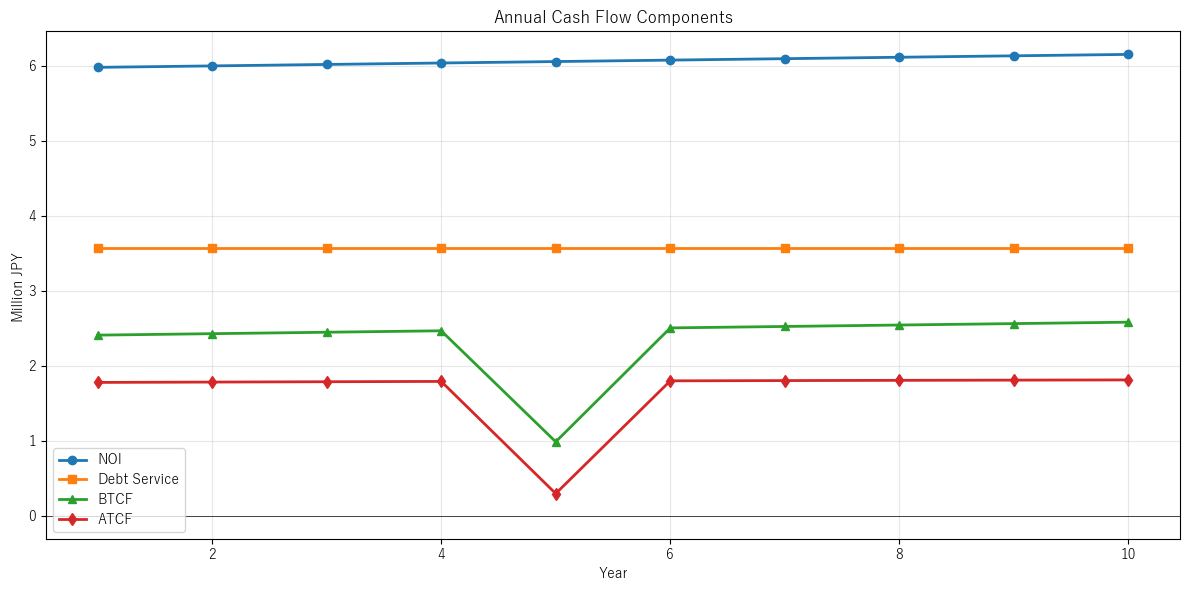

In [40]:
# %%
fig, ax = plt.subplots(figsize=(12, 6))

years = df["year"]
ax.plot(years, df["noi"] / 1e6, marker="o", label="NOI", linewidth=2)
ax.plot(years, df["debt_service"] / 1e6, marker="s", label="Debt Service", linewidth=2)
ax.plot(years, df["btcf"] / 1e6, marker="^", label="BTCF", linewidth=2)
ax.plot(years, df["atcf"] / 1e6, marker="d", label="ATCF", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Annual Cash Flow Components")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

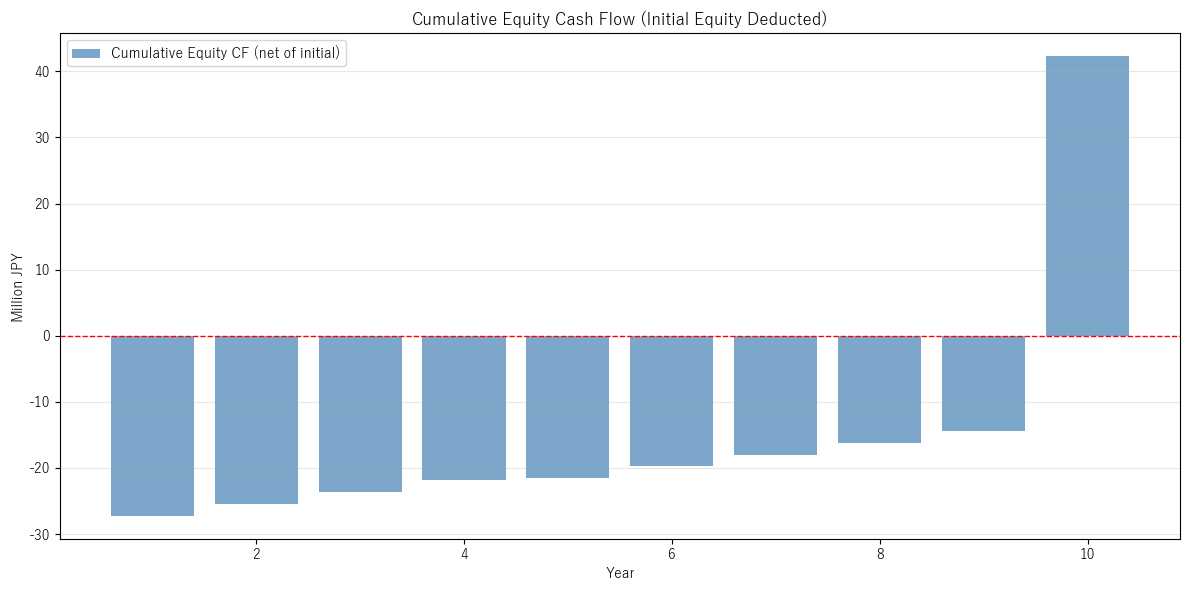

In [41]:
# %%
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df["year"], df["cumulative_equity_cf_with_initial"] / 1e6,
       color="steelblue", alpha=0.7, label="Cumulative Equity CF (net of initial)")
ax.axhline(y=0, color="red", linewidth=1, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Equity Cash Flow (Initial Equity Deducted)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

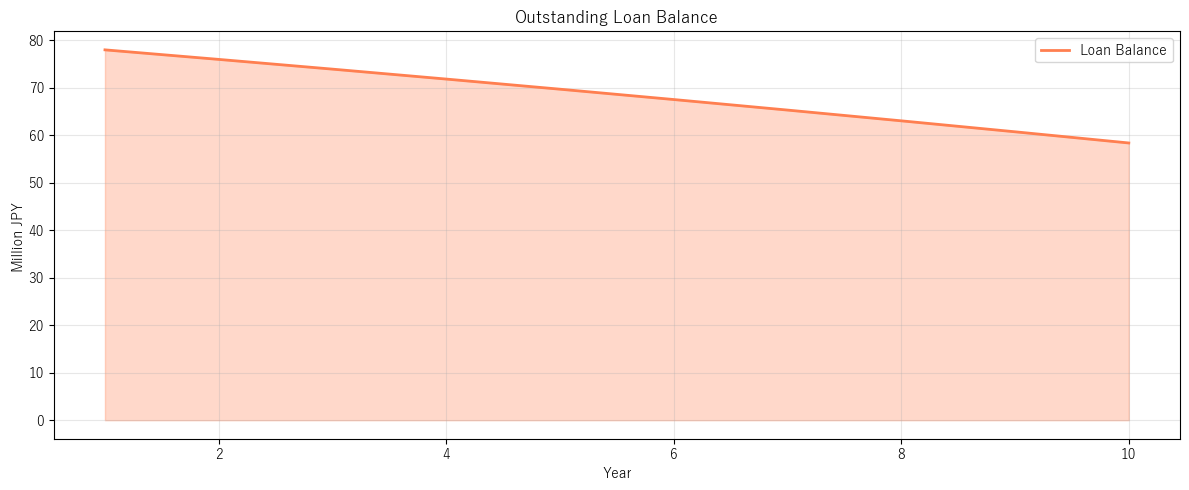

In [42]:
# %%
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df["year"], df["loan_balance_end"] / 1e6, alpha=0.3, color="coral")
ax.plot(df["year"], df["loan_balance_end"] / 1e6, color="coral", linewidth=2, label="Loan Balance")

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Outstanding Loan Balance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## シナリオ分析（感応度分析）

パラメータを変化させた場合の **Equity IRR** や **累積 ATCF** を比較します。

1. **賃料成長率** を変えた場合の Equity IRR
2. **出口 Cap Rate** を変えた場合の Equity IRR
3. **修繕費成長率** を変えた場合の累積 ATCF
4. **Cap Rate vs Component Growth** モード比較

In [43]:
# %%
def run_scenario(base_params, overrides):
    """パラメータを一部変更してシミュレーションを実行する。

    enrich_params を再実行して整合性を保つ。

    Returns:
        df, summary, metrics
    """
    p = deepcopy(base_params)
    p.update(overrides)
    # enrich 対象キーが上書きされた場合に再計算
    if any(k in overrides for k in [
        "transaction_date", "building_completion_ym", "building_structure",
        "building_usage", "steel_thickness_mm", "hold_period_years",
        "inflation_rate", "land_real_appreciation_spread",
        "building_real_appreciation_spread", "ownership_type",
        "income_tax_rate_national", "resident_tax_rate",
        "reconstruction_special_tax_rate",
    ]):
        p = enrich_params(p)
    df_s, summary_s = run_simulation(p)
    metrics_s, df_s = compute_metrics(p, df_s, summary_s)
    return df_s, summary_s, metrics_s

print("run_scenario ヘルパー関数を定義しました。")

run_scenario ヘルパー関数を定義しました。


=== Rent Growth Rate Sensitivity ===
rent_growth_rate  equity_irr  equity_multiple
           -1.0%       6.87%            1.76x
            0.0%       9.71%            2.22x
            0.5%      11.00%            2.46x
            1.0%      12.22%            2.71x
            2.0%      14.48%            3.24x


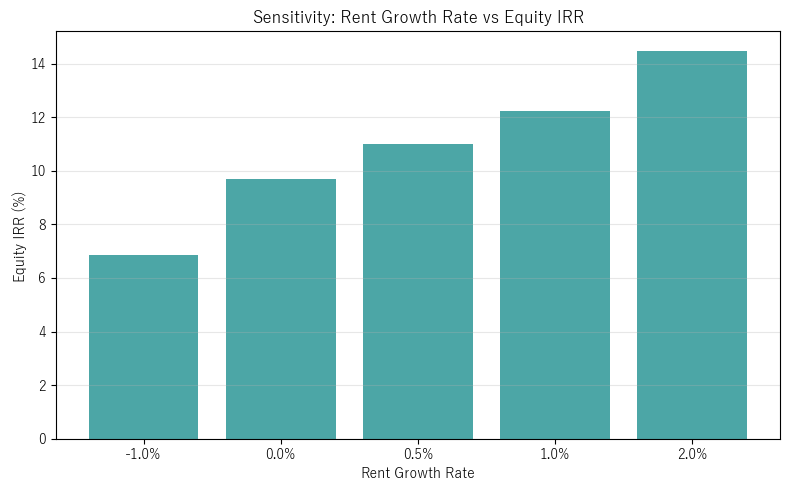

In [44]:
# %%
# --- シナリオ 1: 賃料成長率 vs Equity IRR ---
rent_growth_scenarios = [-0.01, 0.0, 0.005, 0.01, 0.02]
results_rent = []

for rg in rent_growth_scenarios:
    _, _, m = run_scenario(params, {"rent_growth_rate": rg})
    results_rent.append({
        "rent_growth_rate": f"{rg:.1%}",
        "equity_irr": m["equity_irr"],
        "equity_multiple": m["equity_multiple"],
    })

df_rent_scenario = pd.DataFrame(results_rent)
print("=== Rent Growth Rate Sensitivity ===")
print(df_rent_scenario.to_string(index=False, float_format=lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}x"))

fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["equity_irr"] if r["equity_irr"] else 0 for r in results_rent]
ax.bar([r["rent_growth_rate"] for r in results_rent], [x * 100 for x in irrs], color="teal", alpha=0.7)
ax.set_xlabel("Rent Growth Rate")
ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Rent Growth Rate vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

=== Exit Cap Rate Sensitivity ===
exit_cap_rate equity_irr  sale_price net_sale_proceeds
         3.5%     16.27% 175,795,253        95,447,633
         4.0%     14.35% 153,820,846        78,550,188
         4.5%     12.61% 136,729,641        65,407,730
         5.0%     11.00% 123,056,677        54,893,764
         5.5%      9.49% 111,869,706        46,291,428
         6.0%      8.06% 102,547,231        39,122,815


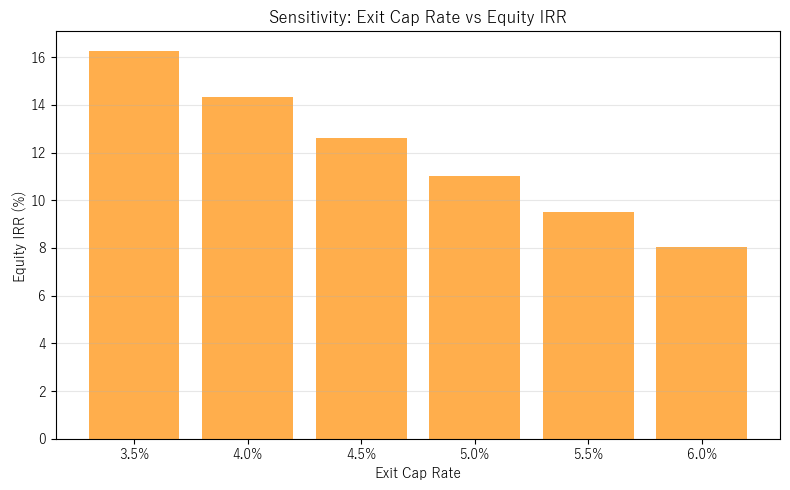

In [45]:
# %%
# --- シナリオ 2: 出口 Cap Rate vs Equity IRR ---
exit_cap_scenarios = [0.035, 0.04, 0.045, 0.05, 0.055, 0.06]
results_exit = []

for ec in exit_cap_scenarios:
    _, s, m = run_scenario(params, {"exit_cap_rate": ec})
    results_exit.append({
        "exit_cap_rate": f"{ec:.1%}",
        "equity_irr": m["equity_irr"],
        "sale_price": s["sale_price_selected"],
        "net_sale_proceeds": s["net_sale_proceeds"],
    })

df_exit_scenario = pd.DataFrame(results_exit)
df_exit_display = df_exit_scenario.copy()
df_exit_display["equity_irr"] = df_exit_display["equity_irr"].apply(lambda x: f"{x:.2%}" if x else "N/A")
df_exit_display["sale_price"] = df_exit_display["sale_price"].apply(lambda x: f"{x:,.0f}")
df_exit_display["net_sale_proceeds"] = df_exit_display["net_sale_proceeds"].apply(lambda x: f"{x:,.0f}")
print("=== Exit Cap Rate Sensitivity ===")
print(df_exit_display.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["equity_irr"] if r["equity_irr"] else 0 for r in results_exit]
ax.bar([r["exit_cap_rate"] for r in results_exit], [x * 100 for x in irrs], color="darkorange", alpha=0.7)
ax.set_xlabel("Exit Cap Rate")
ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Exit Cap Rate vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

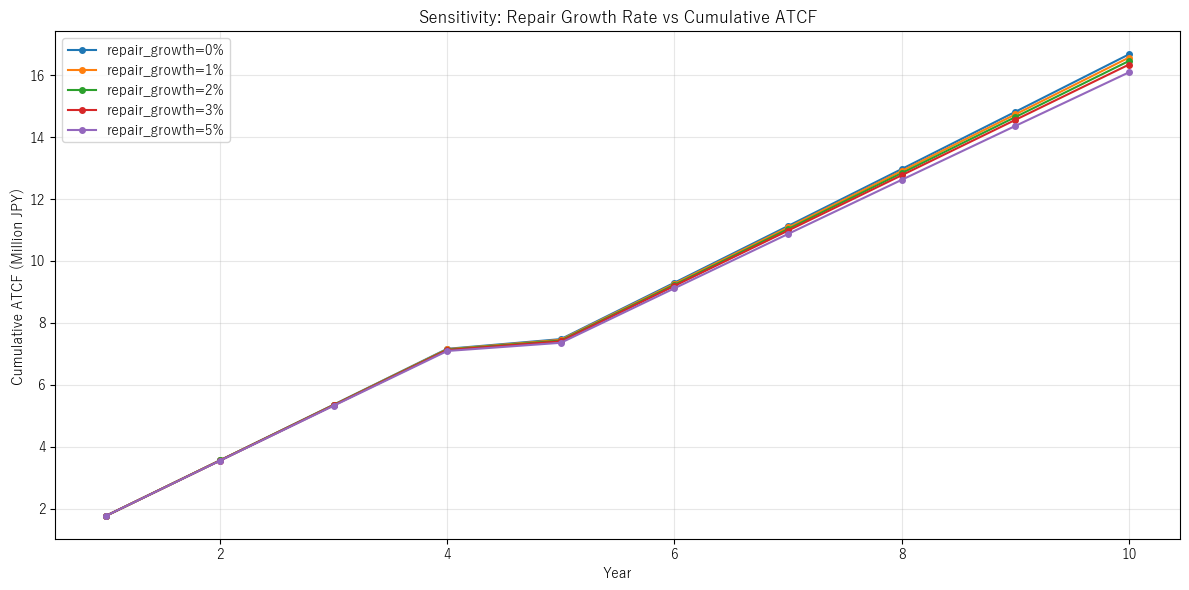

In [46]:
# %%
# --- シナリオ 3: 修繕費成長率 vs 累積ATCF ---
repair_scenarios = [0.0, 0.01, 0.02, 0.03, 0.05]

fig, ax = plt.subplots(figsize=(12, 6))

for rg in repair_scenarios:
    df_s, _, _ = run_scenario(params, {"repair_growth_rate": rg})
    ax.plot(df_s["year"], df_s["cumulative_atcf"] / 1e6,
            marker="o", markersize=4, label=f"repair_growth={rg:.0%}")

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative ATCF (Million JPY)")
ax.set_title("Sensitivity: Repair Growth Rate vs Cumulative ATCF")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 売却価格算定方法の比較

Cap Rate モード vs Component Growth モードの結果を比較します。

In [47]:
# %%
# --- シナリオ 4: 売却価格算定方法の比較 ---
methods = ["cap_rate", "component_growth"]
comparison = []

for method in methods:
    _, s, m = run_scenario(params, {"exit_price_method": method})
    comparison.append({
        "method": method,
        "sale_price": s["sale_price_selected"],
        "net_sale_proceeds": s["net_sale_proceeds"],
        "equity_irr": m["equity_irr"],
        "equity_multiple": m["equity_multiple"],
    })

df_method = pd.DataFrame(comparison)
df_method_disp = df_method.copy()
df_method_disp["sale_price"] = df_method_disp["sale_price"].apply(lambda x: f"{x:,.0f}")
df_method_disp["net_sale_proceeds"] = df_method_disp["net_sale_proceeds"].apply(lambda x: f"{x:,.0f}")
df_method_disp["equity_irr"] = df_method_disp["equity_irr"].apply(lambda x: f"{x:.2%}" if x else "N/A")
df_method_disp["equity_multiple"] = df_method_disp["equity_multiple"].apply(lambda x: f"{x:.2f}x")
print("=== Exit Price Method Comparison ===")
print(df_method_disp.to_string(index=False))

=== Exit Price Method Comparison ===
          method  sale_price net_sale_proceeds equity_irr equity_multiple
        cap_rate 123,056,677        54,893,764     11.00%           2.46x
component_growth 116,603,397        49,931,448     10.15%           2.29x


### 二次元感応度テーブル

賃料成長率 × 出口 Cap Rate の組み合わせで Equity IRR のマトリクスを作成します。

In [48]:
# %%
rent_growth_vals = [-0.005, 0.0, 0.005, 0.01, 0.015]
exit_cap_vals = [0.04, 0.045, 0.05, 0.055, 0.06]

matrix = {}
for rg in rent_growth_vals:
    row = {}
    for ec in exit_cap_vals:
        _, _, m = run_scenario(params, {"rent_growth_rate": rg, "exit_cap_rate": ec})
        irr = m["equity_irr"]
        row[f"Exit {ec:.1%}"] = f"{irr:.2%}" if irr is not None else "N/A"
    matrix[f"Rent {rg:+.1%}"] = row

df_matrix = pd.DataFrame(matrix).T
df_matrix.index.name = "Rent Growth \\ Exit Cap"
print("=== Equity IRR Sensitivity Matrix ===")
df_matrix

=== Equity IRR Sensitivity Matrix ===


,Exit 4.0%,Exit 4.5%,Exit 5.0%,Exit 5.5%,Exit 6.0%
Rent Growth \ Exit Cap,,,,,
Rent -0.5%,11.96%,10.09%,8.34%,6.68%,4.81%
Rent +0.0%,13.18%,11.38%,9.71%,8.13%,6.62%
Rent +0.5%,14.35%,12.61%,11.00%,9.49%,8.06%
Rent +1.0%,15.47%,13.77%,12.22%,10.77%,9.40%
Rent +1.5%,16.54%,14.89%,13.38%,11.98%,10.67%


## 今後の拡張ポイント

### v2 候補（短期的な改善）
- [ ] **月次化**: 年次 → 月次ベースの CF 計算
- [ ] **IO→amortizing 返済方式のテスト**: `amortization_type="interest_only_then_amortizing"` の検証
- [ ] **複数シナリオの自動比較レポート**: HTML / PDF 出力
- [ ] **フォワード NOI ベースの Cap Rate 適用**: 翌年 NOI での売却価格推定

### 税務の精緻化
- [ ] **個人の累進税率**: 所得税率の段階的適用
- [ ] **損益通算**: 不動産所得の赤字を他の所得と通算
- [ ] **欠損繰越**: 最大 3 年間の損失繰越（法人は 10 年）
- [ ] **Depreciation Recapture**: 売却時の減価償却戻入課税の精緻計算
- [ ] **消費税**: 建物部分の消費税取扱い
- [ ] **登録免許税・不動産取得税**: 取得時の個別税目
- [ ] **譲渡所有期間の精緻判定**: 取得日翌日 → 譲渡年1月1日で丁5年超

### 耐用年数・償却の精緻化
- [ ] **用途別テーブル拡張**: office, retail, warehouse 等
- [ ] **設備附属の別途償却**: 建物附属設備（電気、給排水等）の短期償却
- [ ] **大規模修繕の資本化**: Capex を資産計上して追加償却
- [ ] **取得諸費用の資産計上**: 仲介手数料等の償却対象化

### 収入モデルの高度化
- [ ] **賃料改定モデル**: 契約更新時の賃料変動（ステップレント等）
- [ ] **リーシングコスト**: テナント入替時の仲介手数料・フリーレント
- [ ] **空室率の動的モデル**: 築年数・エリア特性に応じた空室率変動
- [ ] **テナント構成**: 複数テナント・異なる契約条件の管理

### 出口戦略
- [ ] **売却タイミング最適化**: 各年の売却 IRR を比較
- [ ] **長期/短期の税率切替シミュレーション**: 5 年±の売却時期比較

### ポートフォリオ・高度分析
- [ ] **複数物件ポートフォリオ**: 物件間の CF 統合・リスク分散分析
- [ ] **モンテカルロシミュレーション**: 賃料・空室率・金利などの確率的変動
- [ ] **感応度ヒートマップ**: 2 変数の組合せ感応度を可視化
- [ ] **ブレークイーブン分析**: 空室率・金利のブレークイーブンポイント

### 技術的改善
- [ ] **クラス設計**: `Property`, `Loan`, `TaxCalculator` 等のオブジェクト化
- [ ] **設定ファイル**: YAML / JSON ベースのパラメータ管理
- [ ] **Web UI**: Streamlit / Gradio によるインタラクティブダッシュボード
- [ ] **データベース連携**: 過去シミュレーション結果の蓄積・比較